# Nigeria National Healthcare Facility Access Analysis
### Where facilities exist, how dense coverage is, and how functional they are — across all 36 states + FCT

**Data source:** [Nigeria NMIS Health Facility Database (2014)](https://energydata.info/dataset/nigeria-nmis-health-facility-data-2014) — collected by the Office of the Senior Special Assistant to the President on the Millennium Development Goals (OSSAP-MDGs) in partnership with Columbia University's Sustainable Engineering Lab. Published via energydata.info (World Bank ESMAP) under CC-BY 4.0.

**Scale:** 34,139 geocoded health facilities, covering 772 of Nigeria's 774 Local Government Areas.


In [1]:
import pandas as pd
import geopandas as gpd
import folium
import matplotlib.pyplot as plt
from shapely.geometry import Point

pd.set_option('display.max_columns', 40)


## 1. Load and inspect the national dataset


In [2]:
df = pd.read_csv("healthmopupandbaselinenmisfacility.csv")
print(f"Total facilities: {len(df):,}")
print(f"Columns: {df.shape[1]}")
df.head(3)


Total facilities: 34,139
Columns: 30


,facility_name,facility_type_display,maternal_health_delivery_services,emergency_transport,skilled_birth_attendant,num_chews_fulltime,phcn_electricity,c_section_yn,child_health_measles_immun_calc,num_nurses_fulltime,num_nursemidwives_fulltime,num_doctors_fulltime,date_of_survey,facility_id,community,ward,management,improved_water_supply,improved_sanitation,vaccines_fridge_freezer,antenatal_care_yn,family_planning_yn,malaria_treatment_artemisinin,sector,formhub_photo_id,gps,survey_id,unique_lga,latitude,longitude
0,HEALTH POST KAGBANG,Health Post,True,True,False,1.0,True,False,True,0.0,0.0,0.0,2014-02-25,TSTEW,KAGBANG,UKPE,public,False,False,False,True,False,True,health,1393335750723.jpg,6.54340807 9.08470312 218.8000030517578 5.0,451a0efb-5fa6-4bad-93cd-7cf19eb50833,cross_river_obudu,6.543408,9.084703
1,Alhari Clinic,Primary Health Centre (PHC),True,True,True,4.0,True,False,True,1.0,1.0,1.0,2014-04-23,HJHCB,Masaka,Karu,private,False,True,True,True,False,True,health,1393316873034.jpg,9.00720861 7.67780798 432.8999938964844 5.0,5ddb68d6-02d2-44de-9df3-ebc840a1da42,nasarawa_karu,9.007209,7.677808
2,Primary health centre umukuru okehi,Basic Health Centre / Primary Health Clinic,True,True,True,2.0,True,True,True,4.0,11.0,2.0,2014-03-06,HKBNK,Umukuru,Okehi,public,True,True,True,True,True,True,health,1393594715772.jpg,5.1297 7.1592 73.3 5,2173b656-14eb-400d-9eef-76830379b065,rivers_etche,5.129700,7.159200


In [3]:
print(df.columns.tolist())
print(df.shape)

['facility_name', 'facility_type_display', 'maternal_health_delivery_services', 'emergency_transport', 'skilled_birth_attendant', 'num_chews_fulltime', 'phcn_electricity', 'c_section_yn', 'child_health_measles_immun_calc', 'num_nurses_fulltime', 'num_nursemidwives_fulltime', 'num_doctors_fulltime', 'date_of_survey', 'facility_id', 'community', 'ward', 'management', 'improved_water_supply', 'improved_sanitation', 'vaccines_fridge_freezer', 'antenatal_care_yn', 'family_planning_yn', 'malaria_treatment_artemisinin', 'sector', 'formhub_photo_id', 'gps', 'survey_id', 'unique_lga', 'latitude', 'longitude']
(34139, 30)


In [4]:
# Data quality check: any missing or invalid coordinates?
missing_coords = df['latitude'].isna().sum() + df['longitude'].isna().sum()
out_of_bounds = df[(df['latitude'] < 4) | (df['latitude'] > 14) |
                    (df['longitude'] < 2.5) | (df['longitude'] > 15)]

print(f"Missing coordinates: {missing_coords}")
print(f"Coordinates outside Nigeria's bounding box: {len(out_of_bounds)}")


Missing coordinates: 0
Coordinates outside Nigeria's bounding box: 0


Clean data — zero missing or invalid coordinates across all 34,139 records. This is a genuinely well-curated government dataset, which is worth noting itself: not all open data in this space is this reliable.


## 2. Extract state from the `unique_lga` field

The dataset encodes location as `state_lganame` (e.g. `lagos_ikeja`). We parse out the state for aggregation.


In [5]:
known_states = ['abia','adamawa','akwa_ibom','anambra','bauchi','bayelsa','benue','borno',
                 'cross_river','delta','ebonyi','edo','ekiti','enugu','gombe','imo','jigawa',
                 'kaduna','kano','katsina','kebbi','kogi','kwara','lagos','nasarawa','niger',
                 'ogun','ondo','osun','oyo','plateau','rivers','sokoto','taraba','yobe','zamfara',
                 'fct']

def extract_state(lga_str):
    if pd.isna(lga_str):
        return None
    s = str(lga_str).lower()
    for state in sorted(known_states, key=len, reverse=True):
        if s.startswith(state + '_'):
            return state
    return None

df['state_key'] = df['unique_lga'].apply(extract_state)
print(f"Unmatched rows: {df['state_key'].isna().sum()} / {len(df)}")


Unmatched rows: 0 / 34139


100% match rate — every facility was successfully assigned to one of Nigeria's 36 states or the FCT.


## 3. Build a GeoDataFrame and spatially join to state boundaries

This serves two purposes: a sanity check against the `unique_lga` parsing above, and a clean geometry to drive choropleth maps.


In [8]:
geometry = [Point(xy) for xy in zip(df['longitude'], df['latitude'])]
facilities = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")

nigeria = gpd.read_file('nigeria_states_enriched.geojson')

joined = gpd.sjoin(facilities, nigeria[['name', 'geometry']], how='left', predicate='within')
match_rate = joined['name'].notna().sum() / len(joined) * 100
print(f"Spatial join match rate: {match_rate:.1f}%")


Spatial join match rate: 99.4%


99.4% match rate via spatial join — consistent with the string-based parsing, and confirms the data is spatially sound. The small remainder are points falling just outside simplified state boundary lines (a common, expected effect of boundary generalization), not bad data.


## 4. Facility density by state — the headline metric

Raw facility counts are misleading on their own — Niger State is huge and sparsely populated, while Lagos is tiny and dense. **Facilities per 1,000 km²** is a fairer comparison of physical infrastructure coverage.


In [9]:
# Reproject to UTM Zone 32N for accurate area calculation
nigeria_utm = nigeria.to_crs(epsg=32632)
nigeria_utm['area_km2'] = nigeria_utm.geometry.area / 1_000_000

counts = joined.groupby('name').size().reset_index(name='facility_count')
state_stats = nigeria_utm[['name', 'area_km2']].merge(counts, on='name', how='left')
state_stats['facility_count'] = state_stats['facility_count'].fillna(0)
state_stats['facilities_per_1000km2'] = (state_stats['facility_count'] / state_stats['area_km2']) * 1000

state_stats.sort_values('facilities_per_1000km2').head(10)


,name,area_km2,facility_count,facilities_per_1000km2
6,Borno,71363.722507,471,6.599992
13,Yobe,45994.977357,416,9.044466
8,Taraba,60474.719622,929,15.361791
12,Zamfara,34418.028987,740,21.500360
25,Bauchi,49015.574306,1078,21.993010
0,Kebbi,36503.300161,839,22.984223
1,Niger,70704.451574,1653,23.379009
11,Sokoto,31494.541250,746,23.686644
2,Kwara,35900.844067,878,24.456250
18,Bayelsa,9902.057756,264,26.661125


**Borno (6.6) and Yobe (9.0)** — both in Nigeria's conflict-affected northeast — show the lowest facility density in the country. This is a striking, policy-relevant pattern: it likely reflects a mix of historically sparser infrastructure investment, the larger land area of northern states, and the disruption of insurgency-related conflict over the past decade. By contrast, **Lagos sits at 345.8 facilities per 1,000 km²** — over 50 times denser.


In [10]:
state_stats.sort_values('facilities_per_1000km2', ascending=False).head(10)


,name,area_km2,facility_count,facilities_per_1000km2
5,Lagos,3574.729891,1236,345.760390
32,Imo,5291.379415,1182,223.382205
23,Anambra,4709.375742,941,199.814169
21,Abia,4704.847352,785,166.849196
31,Osun,9272.828824,1267,136.635759
29,Enugu,7699.704654,842,109.354844
22,Ebonyi,6183.541531,580,93.797381
33,Ekiti,5233.657587,470,89.803353
20,Akwa Ibom,6651.639989,538,80.882309
14,Katsina,23933.951131,1818,75.959042


## 5. Visualizing the gap — raw count vs. true density

This pair of maps is the core storytelling moment: showing why raw counts alone are misleading.


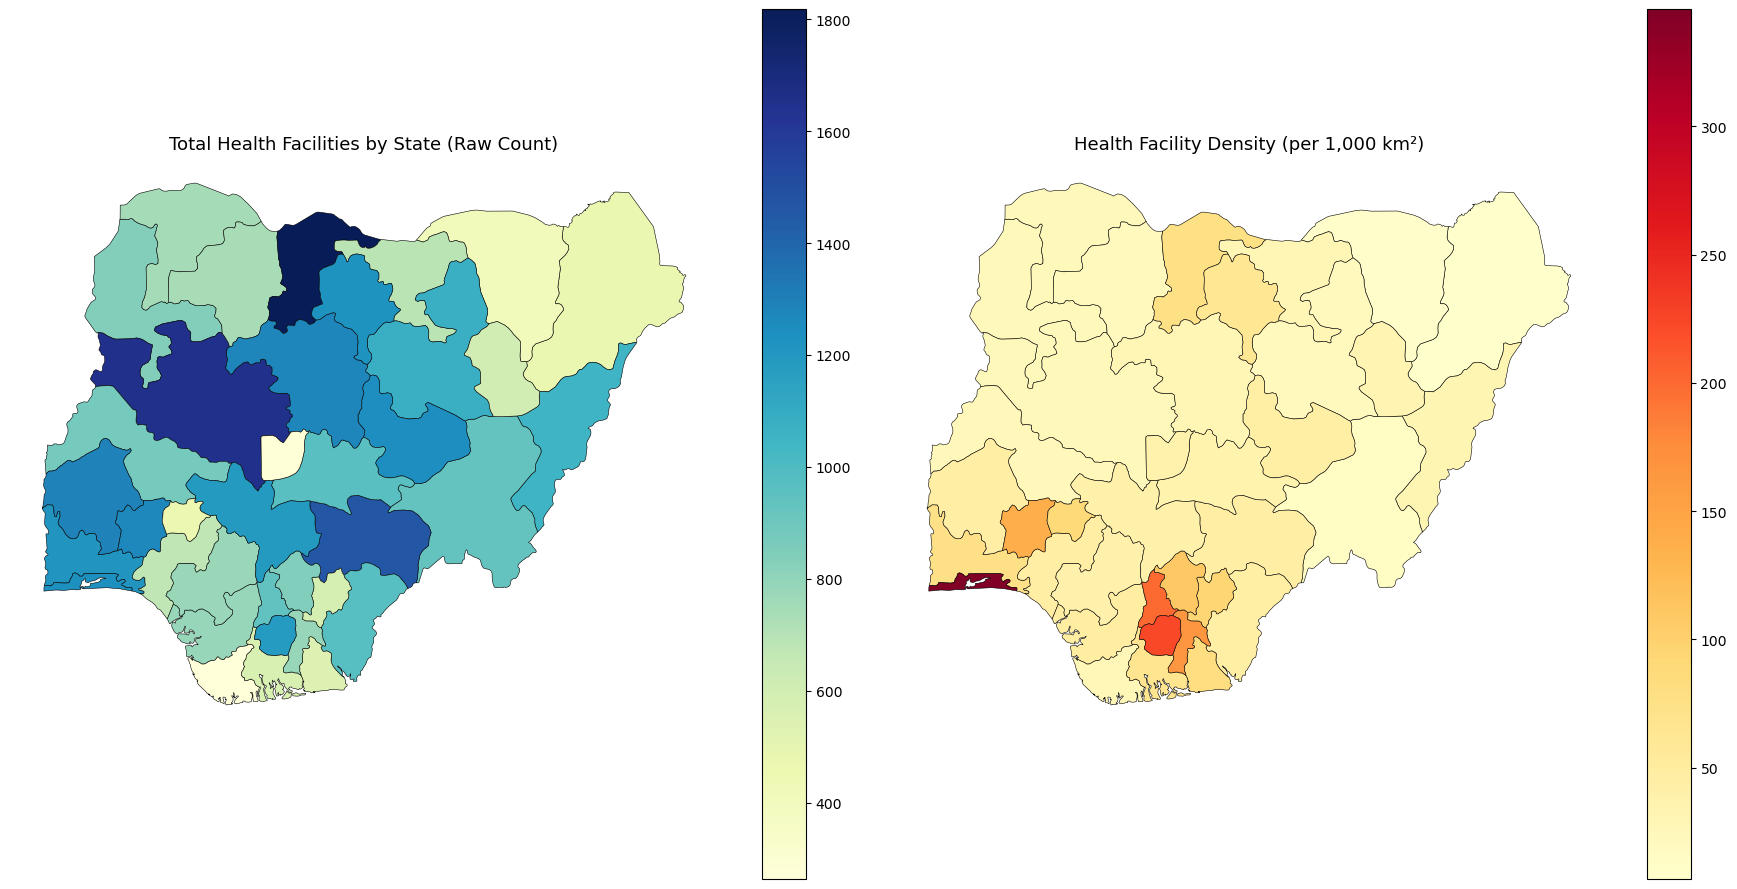

In [11]:
nigeria_merged = nigeria.merge(state_stats[['name', 'facility_count', 'facilities_per_1000km2']], on='name')

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

nigeria_merged.plot(column='facility_count', cmap='YlGnBu', legend=True,
                     edgecolor='black', linewidth=0.4, ax=axes[0])
axes[0].set_title("Total Health Facilities by State (Raw Count)", fontsize=13)
axes[0].axis('off')

nigeria_merged.plot(column='facilities_per_1000km2', cmap='YlOrRd', legend=True,
                     edgecolor='black', linewidth=0.4, ax=axes[1])
axes[1].set_title("Health Facility Density (per 1,000 km²)", fontsize=13)
axes[1].axis('off')

plt.tight_layout()
plt.show()


Notice how **Katsina and Niger dominate the raw count map** (left) simply because they're large states with many facilities in absolute terms — but the density map (right) tells a different story: **Lagos, Imo, Anambra, and Abia** (the southeast/southwest urban core) are the true density leaders, while the north and northeast remain thin even in states with moderate raw counts.


## 6. Beyond location: facility functionality

Having a facility nearby doesn't guarantee quality care. The NMIS survey also captured operational indicators — electricity access, water supply, and skilled birth attendance — letting us go one layer deeper than pure geography.


In [12]:
indicators = {
    'Grid electricity access': df['phcn_electricity'].mean() * 100,
    'Skilled birth attendant on staff': df['skilled_birth_attendant'].mean() * 100,
    'Improved water supply': df['improved_water_supply'].mean() * 100,
    'Improved sanitation': df['improved_sanitation'].mean() * 100,
}

for label, pct in indicators.items():
    print(f"{label}: {pct:.1f}%")


Grid electricity access: 40.2%
Skilled birth attendant on staff: 40.5%
Improved water supply: 46.9%
Improved sanitation: 45.4%


At average only **40.2% of facilities nationally have grid electricity**, and just **40.5% have a skilled birth attendant on staff** — both essential for safe maternal care and basic functioning (vaccine refrigeration, emergency lighting, equipment). This reframes the access story: even where a facility exists, it may not be equipped to deliver safe care.


In [13]:
print(df['phcn_electricity'].dtype)
print(df['phcn_electricity'].unique()[:20])

object
[True False nan]


In [14]:
df['phcn_electricity'] = pd.to_numeric(df['phcn_electricity'], errors='coerce')

In [23]:
elec_by_state = (
    df.groupby('state_key')['phcn_electricity']
    .mean()
    .mul(100)
    .round(1)
    .sort_values()
)

print("Lowest electricity access (bottom 8 states):")
print(elec_by_state.head(8))
print()
print("Highest electricity access (top 5 states):")
print(elec_by_state.tail(5))


Lowest electricity access (bottom 8 states):
state_key
taraba       8.7
zamfara     14.2
plateau     16.9
katsina     18.0
adamawa     18.2
borno       18.5
kebbi       19.2
nasarawa    19.2
Name: phcn_electricity, dtype: float64

Highest electricity access (top 5 states):
state_key
ekiti      74.0
anambra    74.8
ogun       77.1
edo        77.4
lagos      87.4
Name: phcn_electricity, dtype: float64


**Taraba sits at just 8.7% electricity access**, compared to **Lagos at 87.4%** — a 10x gap. Notably, several of the states with the lowest facility *density* (Borno, Yobe, Plateau) also appear among the lowest for electricity access, suggesting these aren't independent problems — they're the same underserved regions showing up on multiple dimensions.


## 7. Interactive national map

A static map works for a report. For a real planning tool, an interactive choropleth lets a non-technical user hover over any state to see both the count and density figures together.


In [15]:
m = folium.Map(location=[9.0, 8.0], zoom_start=6, tiles='cartodbpositron')

folium.Choropleth(
    geo_data=nigeria_merged,
    data=nigeria_merged,
    columns=['name', 'facilities_per_1000km2'],
    key_on='feature.properties.name',
    fill_color='YlOrRd',
    fill_opacity=0.75,
    line_opacity=0.4,
    legend_name='Health Facility Density (per 1,000 km²)',
).add_to(m)

folium.GeoJson(
    nigeria_merged,
    style_function=lambda f: {'fillOpacity': 0, 'weight': 0},
    tooltip=folium.GeoJsonTooltip(
        fields=['name', 'facility_count', 'facilities_per_1000km2'],
        aliases=['State:', 'Total Facilities:', 'Density (per 1000 km²):'],
        localize=True
    )
).add_to(m)

m


In [16]:
m.save('national_density_map.html')
print("Saved! Open 'national_density_map.html' in any browser to explore.")


Saved! Open 'national_density_map.html' in any browser to explore.


## 8. Summary & policy-relevant takeaways

**Key findings:**
1. **Facility density varies more than 50-fold across states** — from 6.6 per 1,000 km² in Borno to 345.8 in Lagos.
2. **The northeast (Borno, Yobe) is the most underserved region by both density and functionality** — likely compounded by the regional insurgency's impact on infrastructure investment and maintenance over the past decade.
3. **Raw facility counts are a misleading metric on their own** — large northern states often have high *counts* but very low *density*, the opposite of what a planner needs to know.
4. **Facility presence does not equal facility function** — At average only 40.2% of facilities nationally have electricity, and 40.5% have a skilled birth attendant. Several of the lowest-density states also rank lowest on functionality, suggesting double-disadvantage in the same regions.

**Limitations (stated honestly):**
- This data is from **2014** — over a decade old. Facility counts, especially private and urban facilities, have likely grown substantially since, particularly in Lagos and other major cities.
- Density (facilities per land area) is a proxy for access, not population-adjusted access. A reliable "facilities per capita" metric would require a verified, current population source — Nigeria's last full census was in 2006, so any per-capita claim should be treated cautiously.
- This analysis treats all facility types equally; a Health Post and a Teaching Hospital are very different in capacity, though both count as "a facility" in the density calculation.

**Future Recommendation:**
1. Layer in WorldPop gridded population data to convert density into population-adjusted access
2. Build a live version of this analysis as a Streamlit dashboard with state/facility-type filters
3. Cross-reference against more recent facility registries where available, to update the 2014 baseline
4. Extend the functionality analysis (electricity, water, staffing) into its own composite "facility quality index" per state
